In [1]:
import pandas as  pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
import sys
import os
sys.path.append("..")

In [3]:
from src.data_preprocessing import LoanDataPreprocessor
from src.feature_engineering import apply_feature_engineering
from src.model_validation import backtesting

In [4]:
with open('../artifacts/pd_model.pkl','rb') as f:
    model=pickle.load(f)

with open('../artifacts/woe_binner.pkl', 'rb') as f:
    woe=pickle.load(f)

with open('../artifacts/final_features.pkl','rb') as f:
    features=pickle.load(f)

In [6]:
data_processor=LoanDataPreprocessor()
df_oot=data_processor.preprocess('../data/loan_data_2015.csv')
df_oot_fe,feature_cols=apply_feature_engineering(df_oot, None)
df_oot_woe=woe.apply_bins(df_oot_fe)
df_oot_woe=woe.transform(df_oot_woe)

INFO:root:Preprocessing version: v1.0
INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 47 columns
INFO:root:final dataset shape: (421094, 80)
INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (421094, 85)
INFO:root:Feature engineering version: v1.0


In [7]:
X_oot=df_oot_woe[features]
y_oot=df_oot_woe['good_bad']

In [8]:
y_pred=model.predict_proba(X_oot)


INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


In [9]:
from src.calibration import PDcalibrator

In [10]:
cal=PDcalibrator()

In [11]:
cal.fit(y_pred,y_oot)

In [12]:
with open('../artifacts/calibration_model.pkl', 'wb') as f:
    pickle.dump(cal, f)

In [13]:
y_pred_cal=cal.predict(y_pred)

In [14]:
from src.model_validation import backtesting

In [15]:
bt_results=backtesting(df_oot_woe,y_oot,y_pred_cal)

C:\Users\welcome\Credit risk project\pipeline\..\src\model_validation.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary=df.groupby('decile').agg(


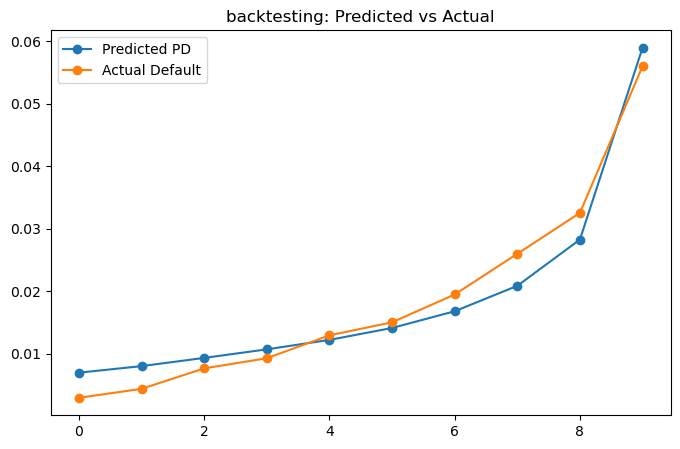

In [16]:
plt.figure(figsize=(8,5))
plt.plot(bt_results['avg_pd'], marker='o', label='Predicted PD')
plt.plot(bt_results['actual_rate'], marker='o', label='Actual Default')
plt.legend()
plt.title('backtesting: Predicted vs Actual')
plt.show()